# CH1 and CH2 Energy Distribution Analysis
Load CH1 and CH2 data, compute integrals for total energy, and create distribution plots.

In [19]:
# Run settings
max_analyzed_events = -1  # -1 = all events, or set a limit for testing

# User configuration
from pathlib import Path

WORKDIR = Path("/Users/virgolaema/Software/3det/Osc_Data")
WAVEFORM_DIR = WORKDIR / "AmBe_therma_coincidence_1750V_3x3_sample"
RESULTS_DIR = Path("./docs/output")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [20]:
from __future__ import annotations

import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import lecroyparser
except ImportError as exc:
    raise ImportError("lecroyparser required. Install: pip install lecroyparser") from exc

# Add AmBe directory to path for lib import
ambe_dir = Path("./AmBe")
if ambe_dir.exists():
    sys.path.insert(0, str(ambe_dir))

try:
    import lib
except ImportError:
    print(f"Warning: Could not import lib from {ambe_dir}")
    print("Continuing with basic functionality only")
    lib = None

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger("ch2_energy")

## Channel 2 (CH2) Analysis

In [21]:
# Find all CH2 files
ch2_files = sorted(WAVEFORM_DIR.glob("C2_*.trc"))
print(f"Found {len(ch2_files)} CH2 files")

if max_analyzed_events > 0:
    ch2_files = ch2_files[:max_analyzed_events]
    print(f"Limited to {len(ch2_files)} files for analysis")

if len(ch2_files) == 0:
    raise ValueError(f"No CH2 files found in {WAVEFORM_DIR}")

Found 11099 CH2 files


In [22]:
def load_waveform(path: Path) -> tuple[np.ndarray, np.ndarray]:
    """Load a single CH2 waveform from LeCroy .trc file.
    
    Returns:
        tuple: (time_ns, voltage_v)
    """
    try:
        # Use parseAll=True to get correct voltage data
        scope = lecroyparser.ScopeData(str(path), parseAll=True)
        time_s = np.asarray(scope.x, dtype=np.float64)
        time_ns = time_s * 1e9
        
        # CH2 files use channel 1 (index 1)
        if isinstance(scope.y, list) and len(scope.y) > 1:
            voltage_v = np.asarray(scope.y[1], dtype=np.float64)
        else:
            # Fallback for single-channel files
            voltage_v = np.asarray(scope.y[0] if isinstance(scope.y, list) else scope.y, dtype=np.float64)
        
        return time_ns, voltage_v
    except Exception as exc:
        logger.error(f"Failed to load {path}: {exc}")
        return None, None


def compute_total_energy(time_ns: np.ndarray, voltage_v: np.ndarray) -> float:
    """Compute total energy as integral of baseline-subtracted waveform.
    
    Energy is computed as the integral of |V - baseline| over time.
    For negative pulses, we integrate the absolute value after baseline subtraction.
    
    Returns:
        float: Total energy in V·ns (volt-nanoseconds)
    """
    # Compute baseline from first 10 samples
    baseline = np.mean(voltage_v[:10])
    
    # Subtract baseline
    signal = voltage_v - baseline
    
    # For negative pulses, take absolute value
    # (Assuming negative polarity based on typical PMT signals)
    signal_abs = np.abs(signal)
    
    # Integrate using trapezoidal rule
    # This gives us V·ns (volt-nanoseconds)
    energy = np.trapezoid(signal_abs, time_ns)
    
    return energy

In [23]:
# Process all CH2 files and compute energies
ch2_energies = []
ch2_failed_count = 0

print(f"Processing {len(ch2_files)} CH2 files...")
for i, ch2_file in enumerate(ch2_files):
    if (i + 1) % 100 == 0:
        print(f"  Processed {i + 1}/{len(ch2_files)} files...")
    
    time_ns, voltage_v = load_waveform(ch2_file)
    
    if time_ns is None or voltage_v is None:
        ch2_failed_count += 1
        continue
    
    energy = compute_total_energy(time_ns, voltage_v)
    ch2_energies.append({
        'file': ch2_file.name,
        'energy_V_ns': energy
    })

print(f"\nCH2 Processing complete!")
print(f"  Successfully processed: {len(ch2_energies)} files")
print(f"  Failed: {ch2_failed_count} files")

# Create DataFrame
df_ch2 = pd.DataFrame(ch2_energies)
print(f"\nCH2 Energy statistics:")
print(df_ch2['energy_V_ns'].describe())

Processing 11099 CH2 files...
  Processed 100/11099 files...
  Processed 200/11099 files...
  Processed 300/11099 files...
  Processed 400/11099 files...
  Processed 500/11099 files...
  Processed 600/11099 files...
  Processed 700/11099 files...
  Processed 800/11099 files...
  Processed 900/11099 files...
  Processed 1000/11099 files...
  Processed 1100/11099 files...
  Processed 1200/11099 files...
  Processed 1300/11099 files...
  Processed 1400/11099 files...
  Processed 1500/11099 files...
  Processed 1600/11099 files...
  Processed 1700/11099 files...
  Processed 1800/11099 files...
  Processed 1900/11099 files...
  Processed 2000/11099 files...
  Processed 2100/11099 files...
  Processed 2200/11099 files...
  Processed 2300/11099 files...
  Processed 2400/11099 files...
  Processed 2500/11099 files...
  Processed 2600/11099 files...
  Processed 2700/11099 files...
  Processed 2800/11099 files...
  Processed 2900/11099 files...
  Processed 3000/11099 files...
  Processed 3100/11

KeyboardInterrupt: 

Plot saved to: docs/output/ch2_energy_distribution.png


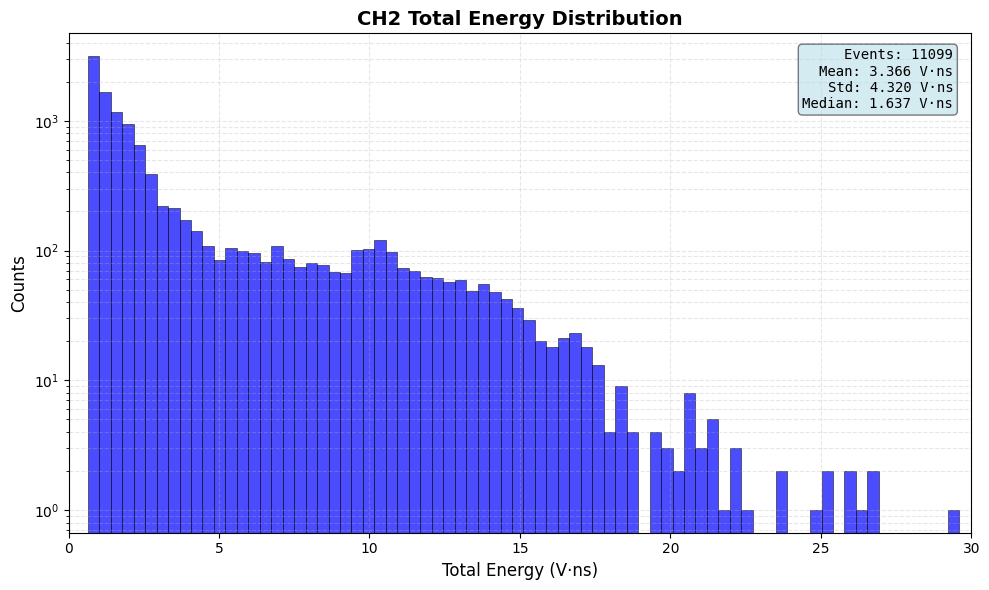

In [ ]:
# Plot CH2 energy distribution
fig, ax = plt.subplots(figsize=(10, 6))

n, bins, patches = ax.hist(df_ch2['energy_V_ns'], bins=500, alpha=0.7, 
                            edgecolor='black', linewidth=0.5, color='blue')

ax.set_xlabel('Total Energy (V·ns)', fontsize=12)
ax.set_ylabel('Counts', fontsize=12)
ax.set_title('CH2 Total Energy Distribution', fontsize=14, fontweight='bold')
ax.set_yscale('log')
ax.set_xlim(right=30)
ax.set_xlim(left=0)

ax.grid(True, alpha=0.3, linestyle='--', which='both')

stats_text = f"""Events: {len(df_ch2)}
Mean: {df_ch2['energy_V_ns'].mean():.3f} V·ns
Std: {df_ch2['energy_V_ns'].std():.3f} V·ns
Median: {df_ch2['energy_V_ns'].median():.3f} V·ns"""
ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5),
        fontsize=10, family='monospace')

plt.tight_layout()
plt.savefig(RESULTS_DIR / "ch2_energy_distribution.png", dpi=150, bbox_inches='tight')
print(f"Plot saved to: {RESULTS_DIR / 'ch2_energy_distribution.png'}")
plt.show()

## Channel 1 (CH1) Analysis

In [ ]:
# Find all CH1 files
ch1_files = sorted(WAVEFORM_DIR.glob("C1_*.trc"))
print(f"Found {len(ch1_files)} CH1 files")

if max_analyzed_events > 0:
    ch1_files = ch1_files[:max_analyzed_events]
    print(f"Limited to {len(ch1_files)} files for analysis")

if len(ch1_files) == 0:
    raise ValueError(f"No CH1 files found in {WAVEFORM_DIR}")

Found 11099 CH1 files


In [ ]:
def load_ch1_waveform(path: Path) -> tuple[np.ndarray, np.ndarray]:
    """Load a single CH1 waveform from LeCroy .trc file.
    
    Returns:
        tuple: (time_ns, voltage_v)
    """
    try:
        scope = lecroyparser.ScopeData(str(path), parseAll=True)
        time_s = np.asarray(scope.x, dtype=np.float64)
        time_ns = time_s * 1e9
        
        # CH1 files use channel 0 (index 0)
        if isinstance(scope.y, list) and len(scope.y) > 0:
            voltage_v = np.asarray(scope.y[0], dtype=np.float64)
        else:
            voltage_v = np.asarray(scope.y if not isinstance(scope.y, list) else scope.y[0], dtype=np.float64)
        
        return time_ns, voltage_v
    except Exception as exc:
        logger.error(f"Failed to load {path}: {exc}")
        return None, None

In [ ]:
# Process all CH1 files and compute energies
ch1_energies = []
ch1_failed_count = 0

print(f"Processing {len(ch1_files)} CH1 files...")
for i, ch1_file in enumerate(ch1_files):
    if (i + 1) % 100 == 0:
        print(f"  Processed {i + 1}/{len(ch1_files)} files...")
    
    time_ns, voltage_v = load_ch1_waveform(ch1_file)
    
    if time_ns is None or voltage_v is None:
        ch1_failed_count += 1
        continue
    
    energy = compute_total_energy(time_ns, voltage_v)
    ch1_energies.append({
        'file': ch1_file.name,
        'energy_V_ns': energy
    })

print(f"\nCH1 Processing complete!")
print(f"  Successfully processed: {len(ch1_energies)} files")
print(f"  Failed: {ch1_failed_count} files")

# Create DataFrame
df_ch1 = pd.DataFrame(ch1_energies)
print(f"\nCH1 Energy statistics:")
print(df_ch1['energy_V_ns'].describe())

Processing 11099 CH1 files...
  Processed 100/11099 files...
  Processed 200/11099 files...
  Processed 300/11099 files...
  Processed 400/11099 files...
  Processed 500/11099 files...
  Processed 600/11099 files...
  Processed 700/11099 files...
  Processed 800/11099 files...
  Processed 900/11099 files...
  Processed 1000/11099 files...
  Processed 1100/11099 files...
  Processed 1200/11099 files...
  Processed 1300/11099 files...
  Processed 1400/11099 files...
  Processed 1500/11099 files...
  Processed 1600/11099 files...
  Processed 1700/11099 files...
  Processed 1800/11099 files...
  Processed 1900/11099 files...
  Processed 2000/11099 files...
  Processed 2100/11099 files...
  Processed 2200/11099 files...
  Processed 2300/11099 files...
  Processed 2400/11099 files...
  Processed 2500/11099 files...
  Processed 2600/11099 files...
  Processed 2700/11099 files...
  Processed 2800/11099 files...
  Processed 2900/11099 files...
  Processed 3000/11099 files...
  Processed 3100/11

Plot saved to: docs/output/ch1_energy_distribution.png


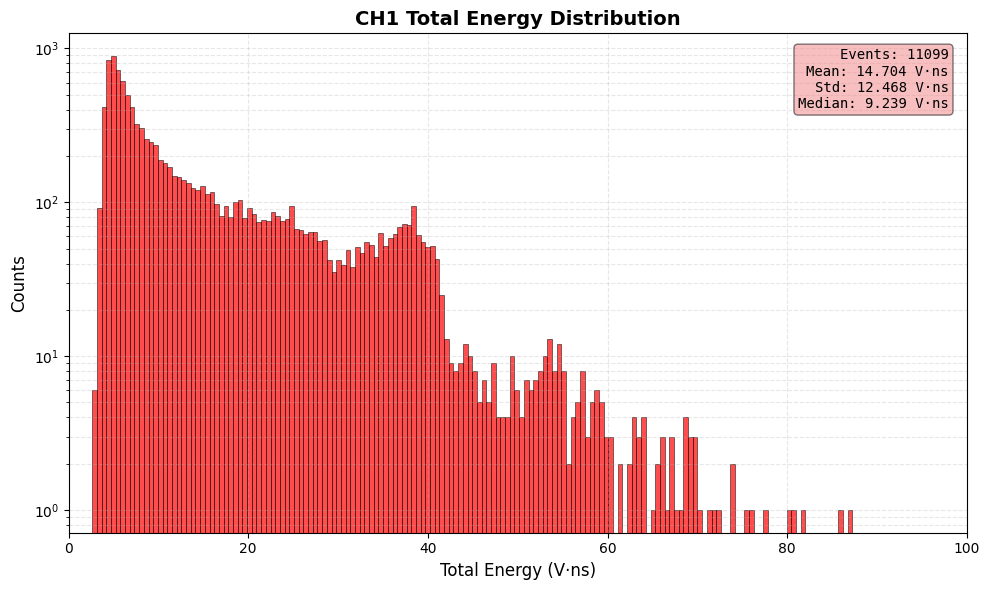

In [ ]:
# Plot CH1 energy distribution
fig, ax = plt.subplots(figsize=(10, 6))

n, bins, patches = ax.hist(df_ch1['energy_V_ns'], bins=300, alpha=0.7, 
                            edgecolor='black', linewidth=0.5, color='red')

ax.set_xlabel('Total Energy (V·ns)', fontsize=12)
ax.set_ylabel('Counts', fontsize=12)
ax.set_title('CH1 Total Energy Distribution', fontsize=14, fontweight='bold')
ax.set_yscale('log')
ax.set_xlim(right=100)
ax.set_xlim(left=0)

ax.grid(True, alpha=0.3, linestyle='--', which='both')

stats_text = f"""Events: {len(df_ch1)}
Mean: {df_ch1['energy_V_ns'].mean():.3f} V·ns
Std: {df_ch1['energy_V_ns'].std():.3f} V·ns
Median: {df_ch1['energy_V_ns'].median():.3f} V·ns"""
ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5),
        fontsize=10, family='monospace')

# add a Compton fit and compton edge and photoelectric peak estimate


plt.tight_layout()
plt.savefig(RESULTS_DIR / "ch1_energy_distribution.png", dpi=150, bbox_inches='tight')
print(f"Plot saved to: {RESULTS_DIR / 'ch1_energy_distribution.png'}")
plt.show()

### Compton Edge and Photoelectric Peak Analysis

In [35]:
from scipy.optimize import curve_fit
from scipy.signal import find_peaks, savgol_filter
from scipy.special import erf

def compton_continuum(x, A, B, C, edge):
    """Compton continuum model: exponential decay up to edge."""
    return A * np.exp(-B * x) * (1 - 0.5 * (1 + erf((x - edge) / C)))

def gaussian(x, amp, mu, sigma):
    """Gaussian peak model."""
    return amp * np.exp(-0.5 * ((x - mu) / sigma)**2)

def find_compton_edge(energies, counts, energy_range=(2, 100)):
    """Find the Compton edge by looking for the shoulder in the spectrum.
    
    Args:
        energies: Energy bin centers
        counts: Histogram counts
        energy_range: Range to search for Compton edge
    
    Returns:
        compton_edge: Estimated Compton edge position
        fit_params: Parameters of the Compton continuum fit
    """
    # Mask to energy range of interest
    mask = (energies >= energy_range[0]) & (energies <= energy_range[1])
    e_fit = energies[mask]
    c_fit = counts[mask]
    
    # Initial guess for Compton edge (around 60-70% of max energy in range)
    edge_guess = energy_range[0] + 0.65 * (energy_range[1] - energy_range[0])
    
    try:
        # Fit Compton continuum
        p0 = [np.max(c_fit), 0.3, 1.0, edge_guess]
        popt, _ = curve_fit(compton_continuum, e_fit, c_fit, p0=p0, maxfev=5000)
        return popt[3], popt  # Return edge position and all params
    except:
        # If fit fails, estimate from derivative
        derivative = np.gradient(c_fit, e_fit)
        edge_idx = np.argmin(derivative)  # Steepest drop
        return e_fit[edge_idx], None

def find_photopeak(energies, counts, energy_range=(8, 100)):
    """Find the photoelectric peak (full energy peak).
    
    Args:
        energies: Energy bin centers
        counts: Histogram counts
        energy_range: Range to search for photopeak
    
    Returns:
        peak_position: Energy of the photopeak
        peak_height: Height of the photopeak
        fit_params: Gaussian fit parameters (amp, mu, sigma)
    """
    # Mask to energy range
    mask = (energies >= energy_range[0]) & (energies <= energy_range[1])
    e_fit = energies[mask]
    c_fit = counts[mask]
    
    # Smooth the data to find peaks more reliably
    if len(c_fit) > 10:
        window = min(11, len(c_fit) if len(c_fit) % 2 == 1 else len(c_fit) - 1)
        c_smooth = savgol_filter(c_fit, window, 3)
    else:
        c_smooth = c_fit
    
    # Find peaks
    peaks, properties = find_peaks(c_smooth, prominence=np.max(c_smooth)*0.1, width=2)
    
    if len(peaks) > 0:
        # Take the highest peak
        highest_peak_idx = peaks[np.argmax(c_smooth[peaks])]
        peak_energy = e_fit[highest_peak_idx]
        peak_height = c_smooth[highest_peak_idx]
        
        # Try to fit Gaussian around the peak
        try:
            # Define fitting window around peak
            fit_window = 2.0  # V·ns
            fit_mask = (e_fit >= peak_energy - fit_window) & (e_fit <= peak_energy + fit_window)
            e_peak = e_fit[fit_mask]
            c_peak = c_fit[fit_mask]
            
            p0 = [peak_height, peak_energy, 0.5]
            popt, _ = curve_fit(gaussian, e_peak, c_peak, p0=p0, maxfev=5000)
            return popt[1], popt[0], popt  # mu, amp, all params
        except:
            return peak_energy, peak_height, None
    else:
        # No clear peak found
        max_idx = np.argmax(c_fit)
        return e_fit[max_idx], c_fit[max_idx], None

In [49]:
# Create histogram data for fitting
counts, bin_edges = np.histogram(df_ch1['energy_V_ns'], bins=200, range=(0, 100))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Find Compton edge
print("Finding Compton edge...")
compton_edge, compton_params = find_compton_edge(bin_centers, counts, energy_range=(5, 80))
print(f"Compton edge estimated at: {compton_edge:.3f} V·ns")

# Find photoelectric peak
print("\nFinding photoelectric peak...")
photopeak_pos, photopeak_height, photopeak_params = find_photopeak(bin_centers, counts, energy_range=(30, 60))
print(f"Photoelectric peak at: {photopeak_pos:.3f} V·ns")
print(f"Peak height: {photopeak_height:.1f} counts")

# Calculate Compton/Photopeak ratio
if photopeak_pos > 0:
    ratio = compton_edge / photopeak_pos
    print(f"\nCompton edge / Photopeak ratio: {ratio:.3f}")
    print(f"(Theoretical for single Compton scatter: ~0.66-0.75)")

Finding Compton edge...
Compton edge estimated at: 62.085 V·ns

Finding photoelectric peak...
Photoelectric peak at: 37.851 V·ns
Peak height: 74.0 counts

Compton edge / Photopeak ratio: 1.640
(Theoretical for single Compton scatter: ~0.66-0.75)


/var/folders/xp/sz23q3kx0jlg35pzq8v76qvm0000gn/T/ipykernel_81985/4191528450.py:36: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(compton_continuum, e_fit, c_fit, p0=p0, maxfev=5000)



Plot saved to: docs/output/ch1_compton_analysis.png


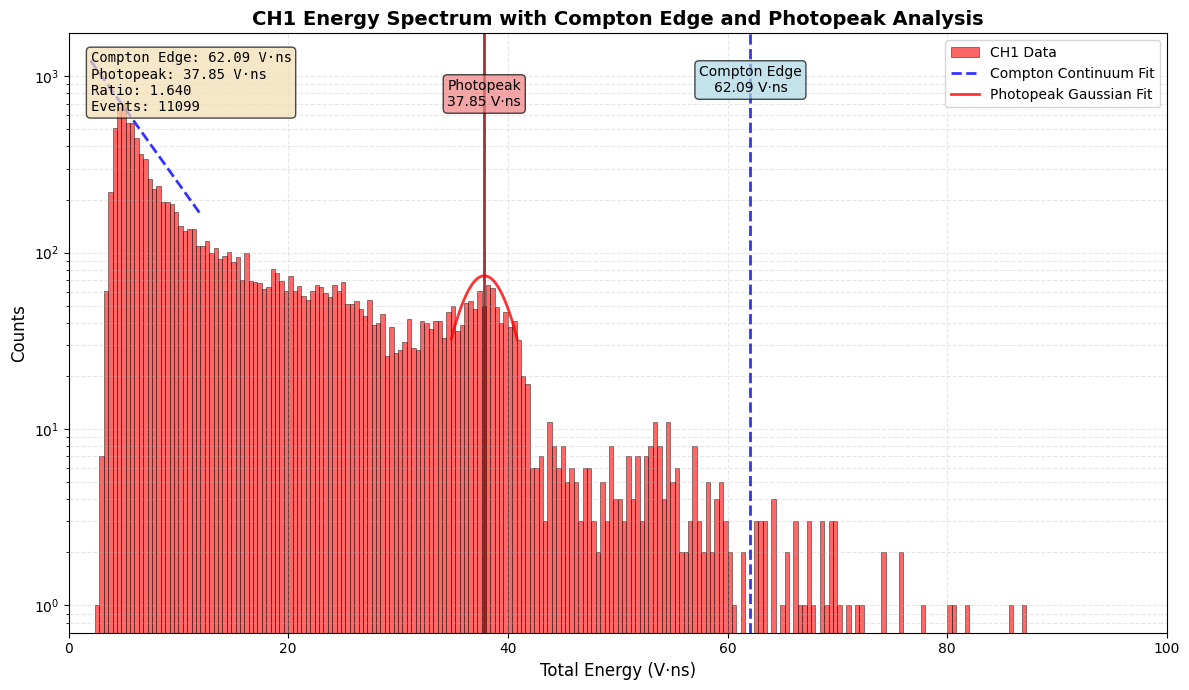

In [50]:
# Plot CH1 energy distribution with Compton and photopeak analysis
fig, ax = plt.subplots(figsize=(12, 7))

# Plot histogram
ax.hist(df_ch1['energy_V_ns'], bins=250, range=(0, 100), alpha=0.6, 
        edgecolor='black', linewidth=0.5, color='red', label='CH1 Data')

# Plot Compton continuum fit if available
if compton_params is not None:
    x_fit = np.linspace(2, 12, 200)
    y_fit = compton_continuum(x_fit, *compton_params)
    ax.plot(x_fit, y_fit, 'b--', linewidth=2, label='Compton Continuum Fit', alpha=0.8)

# Mark Compton edge
y_max = ax.get_ylim()[1]
ax.axvline(compton_edge, color='blue', linestyle='--', linewidth=2, alpha=0.8)
ax.text(compton_edge, y_max*0.9, f'Compton Edge\n{compton_edge:.2f} V·ns', 
        ha='center', va='top', fontsize=10, 
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

# Mark photoelectric peak
ax.axvline(photopeak_pos, color='darkred', linestyle='-', linewidth=2, alpha=0.8)
ax.text(photopeak_pos, y_max*0.75, f'Photopeak\n{photopeak_pos:.2f} V·ns', 
        ha='center', va='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))

# Plot Gaussian fit for photopeak if available
if photopeak_params is not None:
    x_peak = np.linspace(photopeak_pos - 3, photopeak_pos + 3, 100)
    y_peak = gaussian(x_peak, *photopeak_params)
    ax.plot(x_peak, y_peak, 'r-', linewidth=2, label='Photopeak Gaussian Fit', alpha=0.8)

ax.set_xlabel('Total Energy (V·ns)', fontsize=12)
ax.set_ylabel('Counts', fontsize=12)
ax.set_title('CH1 Energy Spectrum with Compton Edge and Photopeak Analysis', 
             fontsize=14, fontweight='bold')
ax.set_yscale('log')
ax.set_xlim(0, 100)
ax.grid(True, alpha=0.3, linestyle='--', which='both')
ax.legend(loc='upper right', fontsize=10)

# Add analysis summary
summary_text = f"""Compton Edge: {compton_edge:.2f} V·ns
Photopeak: {photopeak_pos:.2f} V·ns
Ratio: {compton_edge/photopeak_pos:.3f}
Events: {len(df_ch1)}"""
ax.text(0.02, 0.97, summary_text, transform=ax.transAxes,
        verticalalignment='top', horizontalalignment='left',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7),
        fontsize=10, family='monospace')

plt.tight_layout()
plt.savefig(RESULTS_DIR / "ch1_compton_analysis.png", dpi=150, bbox_inches='tight')
print(f"\nPlot saved to: {RESULTS_DIR / 'ch1_compton_analysis.png'}")
plt.show()

In [51]:
# Save Compton analysis results
compton_results = {
    'compton_edge_V_ns': compton_edge,
    'photopeak_position_V_ns': photopeak_pos,
    'photopeak_height': photopeak_height,
    'compton_photopeak_ratio': compton_edge / photopeak_pos if photopeak_pos > 0 else np.nan,
    'n_events': len(df_ch1)
}

import json
with open(RESULTS_DIR / 'ch1_compton_analysis.json', 'w') as f:
    json.dump(compton_results, f, indent=2)

print("Compton analysis results saved to: ch1_compton_analysis.json")
print(json.dumps(compton_results, indent=2))

Compton analysis results saved to: ch1_compton_analysis.json
{
  "compton_edge_V_ns": 62.08536924942687,
  "photopeak_position_V_ns": 37.85050944653427,
  "photopeak_height": 73.9711275618895,
  "compton_photopeak_ratio": 1.6402782989519744,
  "n_events": 11099
}


## Save Results

In [ ]:
# Save CH2 results to CSV
output_csv_ch2 = RESULTS_DIR / "ch2_energy_data.csv"
df_ch2.to_csv(output_csv_ch2, index=False)
print(f"CH2 data saved to: {output_csv_ch2}")
print(f"Total CH2 events: {len(df_ch2)}")

# Save CH1 results to CSV
output_csv_ch1 = RESULTS_DIR / "ch1_energy_data.csv"
df_ch1.to_csv(output_csv_ch1, index=False)
print(f"\nCH1 data saved to: {output_csv_ch1}")
print(f"Total CH1 events: {len(df_ch1)}")

CH2 data saved to: docs/output/ch2_energy_data.csv
Total CH2 events: 11099

CH1 data saved to: docs/output/ch1_energy_data.csv
Total CH1 events: 11099
